In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
# Load Dataset

train = pd.read_csv("../datasets/dataset1/KDDTrain+.txt", header=None)
test = pd.read_csv("../datasets/dataset1/KDDTest+.txt", header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (125973, 43)
Test shape: (22544, 43)


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
# Step 3: Add column names

columns = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
"wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
"root_shell","su_attempted","num_root","num_file_creations","num_shells",
"num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
"count","srv_count","serror_rate","srv_serror_rate","rerror_rate",
"srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
"dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
"dst_host_diff_srv_rate","dst_host_same_src_port_rate",
"dst_host_srv_diff_host_rate","dst_host_serror_rate",
"dst_host_srv_serror_rate","dst_host_rerror_rate",
"dst_host_srv_rerror_rate","label","difficulty"
]

train.columns = columns
test.columns = columns


# Step 4: Convert labels to Normal and Attack

train['label'] = train['label'].apply(lambda x: "Normal" if x=="normal" else "Attack")
test['label'] = test['label'].apply(lambda x: "Normal" if x=="normal" else "Attack")


# Step 5: Remove difficulty column

train = train.drop("difficulty", axis=1)
test = test.drop("difficulty", axis=1)


# Step 6: Check dataset

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nLabel distribution:")
print(train['label'].value_counts())

train.head()

Train shape: (125973, 42)
Test shape: (22544, 42)

Label distribution:
label
Normal    67343
Attack    58630
Name: count, dtype: int64


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,Normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,Normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,Attack
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,Normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Normal


In [5]:
# Step 7: Convert categorical features to numeric using one-hot encoding

train = pd.get_dummies(train, columns=["protocol_type","service","flag"])
test = pd.get_dummies(test, columns=["protocol_type","service","flag"])

# Align columns of train and test dataset
train, test = train.align(test, join="left", axis=1, fill_value=0)

print("Train shape after encoding:", train.shape)
print("Test shape after encoding:", test.shape)

Train shape after encoding: (125973, 123)
Test shape after encoding: (22544, 123)


In [6]:
# Step 8: Separate features and labels

X_train = train.drop("label", axis=1)
y_train = train["label"]

X_test = test.drop("label", axis=1)
y_test = test["label"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (125973, 122)
X_test shape: (22544, 122)


In [7]:
# Step 9: Convert labels to numeric

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Labels converted successfully")

Labels converted successfully


In [8]:
# Step 10: Fix labels and features

y_train = train["label"]
y_test = test["label"]

X_train = train.drop("label", axis=1)
X_test = test.drop("label", axis=1)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [9]:
# Step 11: Import machine learning models

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [10]:
# Step 12: Train Random Forest model

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7676987224982257


In [11]:
# Step 13: Train KNN model

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7658800567778566


In [12]:
# Step 13: Train SVM model (faster version)

from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.6767654364797729


In [ ]:
# Step 15: Compare model accuracies

print("Random Forest Accuracy:", rf_accuracy)
print("KNN Accuracy:", knn_accuracy)
print("SVM Accuracy:", svm_accuracy)

Random Forest Accuracy: 0.7676987224982257
KNN Accuracy: 0.7658800567778566
SVM Accuracy: 0.6767654364797729


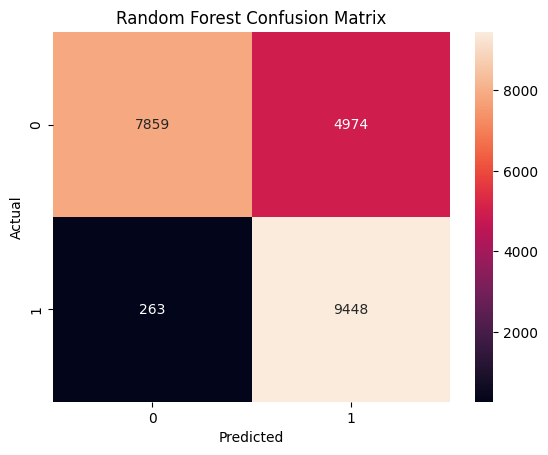

In [15]:
# Step 16: Confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

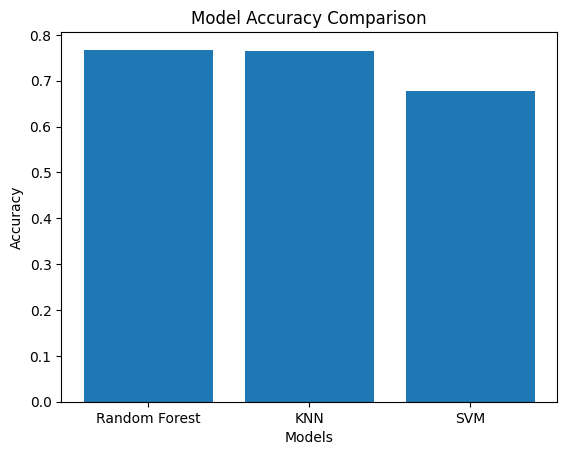

In [16]:
# Step 17: Model accuracy comparison

models = ["Random Forest", "KNN", "SVM"]
accuracies = [rf_accuracy, knn_accuracy, svm_accuracy]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()

In [33]:
# Step 18: Load dataset2 files

import os

path = "../datasets/dataset2"

files = os.listdir(path)

dataframes = []

for file in files:
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(path, file))
        dataframes.append(df)

cicids = pd.concat(dataframes, ignore_index=True)

print("Dataset2 shape:", cicids.shape)

cicids.head()

Dataset2 shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [34]:
# Step 19: Clean dataset

cicids = cicids.dropna()

print("Shape after cleaning:", cicids.shape)

Shape after cleaning: (2829385, 79)


In [35]:
# Step 20: Convert labels

cicids[" Label"] = cicids[" Label"].apply(lambda x: "Normal" if x=="BENIGN" else "Attack")

cicids[" Label"].value_counts()

 Label
Normal    2272688
Attack     556697
Name: count, dtype: int64

In [36]:
# Step 21: Take sample for faster training

cicids = cicids.sample(n=50000, random_state=42)

print("Sampled dataset shape:", cicids.shape)

Sampled dataset shape: (50000, 79)


In [37]:
# Step 22: Split features and labels

X = cicids.drop(" Label", axis=1)
y = cicids[" Label"]

In [38]:
# Step 23: Encode labels

from sklearn.preprocessing import LabelEncoder

le2 = LabelEncoder()

y = le2.fit_transform(y)

In [ ]:
# Step 24: Fix infinity / large values properly

import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)

mask = X.notna().all(axis=1)

X = X[mask]
y = y[mask]

print("Cleaned dataset shape:", X.shape)

Cleaned dataset shape: (49976, 78)


In [ ]:
# Step 25: Split dataset2 into train and test

from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train2.shape, X_test2.shape)

(39980, 78) (9996, 78)


In [ ]:
# Step 26: Train Random Forest on dataset2

rf2 = RandomForestClassifier(n_estimators=100)

rf2.fit(X_train2, y_train2)

rf2_pred = rf2.predict(X_test2)

rf2_accuracy = accuracy_score(y_test2, rf2_pred)

print("Random Forest Accuracy (Dataset2):", rf2_accuracy)

Random Forest Accuracy (Dataset2): 0.9974989995998399


In [42]:
# Step 27: Train KNN on Dataset2

knn2 = KNeighborsClassifier(n_neighbors=5)

knn2.fit(X_train2, y_train2)

knn2_pred = knn2.predict(X_test2)

knn2_accuracy = accuracy_score(y_test2, knn2_pred)

print("KNN Accuracy (Dataset2):", knn2_accuracy)

KNN Accuracy (Dataset2): 0.9775910364145658


In [46]:
# Step 28: Train SVM on Dataset2

from sklearn.svm import LinearSVC

svm2 = LinearSVC()

svm2.fit(X_train2, y_train2)

svm2_pred = svm2.predict(X_test2)

svm2_accuracy = accuracy_score(y_test2, svm2_pred)

print("SVM Accuracy (Dataset2):", svm2_accuracy)

SVM Accuracy (Dataset2): 0.8939575830332133


c:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [47]:
# Step 29: Compare Model Accuracy for Dataset2

print("Random Forest Accuracy:", rf2_accuracy)
print("KNN Accuracy:", knn2_accuracy)
print("SVM Accuracy:", svm2_accuracy)

Random Forest Accuracy: 0.9974989995998399
KNN Accuracy: 0.9775910364145658
SVM Accuracy: 0.8939575830332133


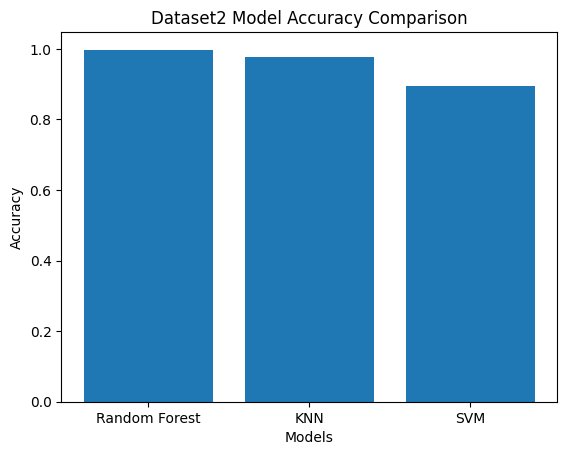

In [48]:
# Step 30: Accuracy comparison for Dataset2

models = ["Random Forest", "KNN", "SVM"]
accuracies = [rf2_accuracy, knn2_accuracy, svm2_accuracy]

import matplotlib.pyplot as plt

plt.figure()
plt.bar(models, accuracies)
plt.title("Dataset2 Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [50]:
# Step 31:

import joblib

# Save model trained on Dataset1
joblib.dump(rf, "../models/nsl_kdd_model.pkl")

# Save model trained on Dataset2
joblib.dump(rf2, "../models/cicids_model.pkl")

['../models/cicids_model.pkl']